[[0.8948622571, 1.027571204, 0.01943833458], [0.4329493442, 1.002474758, 0.04212027945], [0.2892628529, 0.9852837326, 0.01664219444], [0.2356489198, 0.8674656318, 0.08462216863], [-0.02804921181, 0.9008774071, 0.08090992761], [0.9269800969, 1.079469873, -0.01346158002], [0.6813017895, 1.047120604, -0.002113846438], [0.1413635342, 0.8246912863, 0.06646845665], [0.2801257749, 0.8515574052, 0.0147413888], [1.169047787, 1.183110213, 0.04756632148], [0.727158156, 1.159108344, 0.05686722432], [0.3869192378, 1.146364823, 0.05752774944], [1.770150665, 1.13648388, 0.004674795569], [0.5249999761, 1.121591035, 0.05251530362], [0.09579945124, 1.119452852, 0.04766922117], [0.3516436375, 1.173210714, 0.07120222347], [1.624549858, 0.9810009134, 0.0192717002], [1.094358999, 0.9315924359, 0.03929536816], [0.644171476, 0.9246757235, 0.06406210982], [1.191160828, 0.8873485575, 0.01389148255], [1.870135077, 0.8620459176, 0.002232798699], [1.766105042, 0.9532948185, -0.01100931094], [1.063178617, 0.8102539

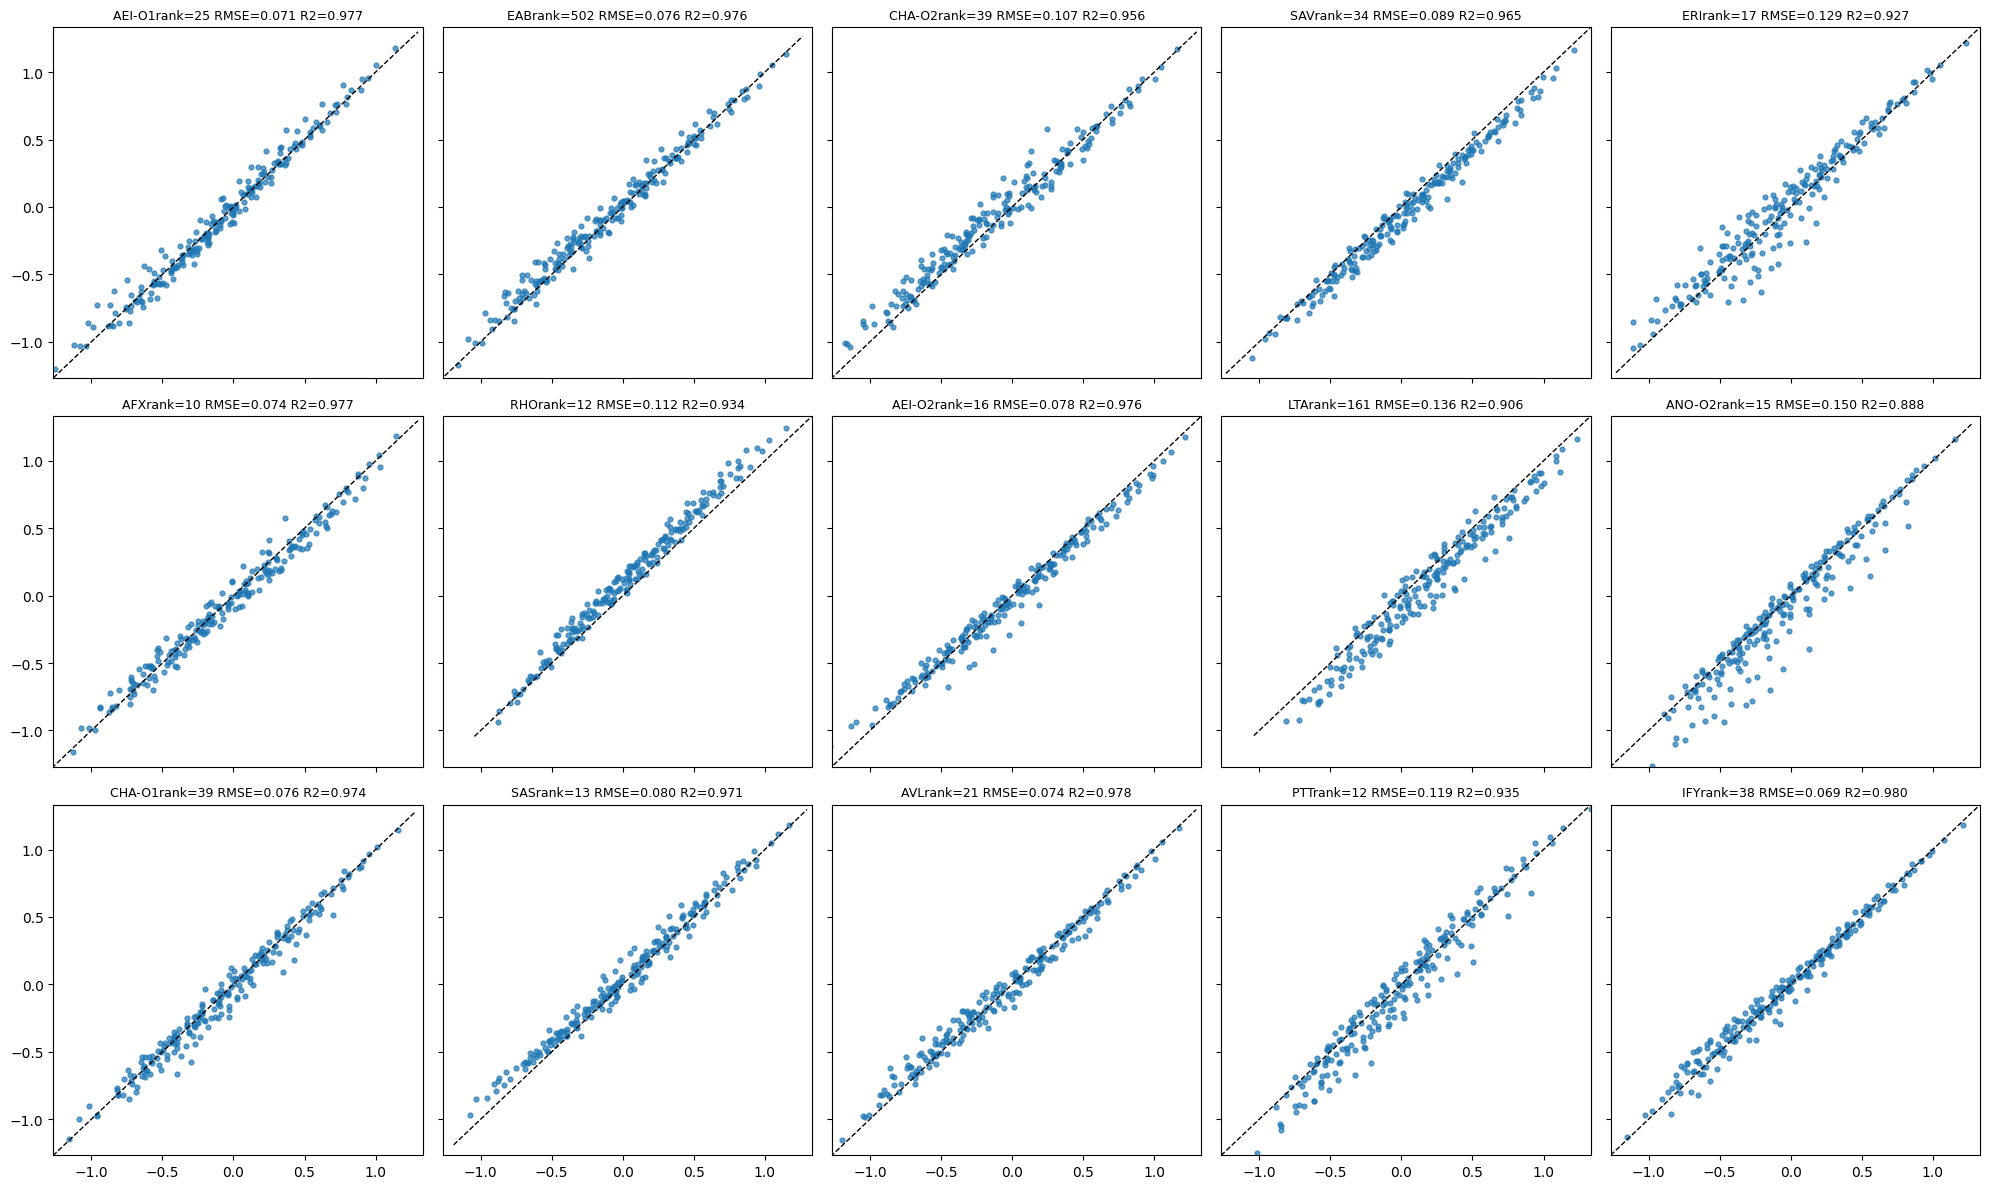

In [ ]:
from pathlib import Path
import math
import matplotlib.pyplot as plt
import mt_sisso_scatter as m
import pandas as pd 
df = pd.read_csv('/Users/jayeee/Desktop/code/SRIPT/sisso-out/2D1-small-M-all/small_mole_2D-1.csv')
def str2list(str):
    return [t.strip() for t in str.strip("[]").split(",") if t.strip()]
f_idx = 10
tasks=df.iloc[f_idx]['task_list']
ranks = df.iloc[f_idx]['ranks']
tasks = str2list(tasks)
ranks = str2list(ranks)
# print(ranks)
folder = [Path('.') / t for t in tasks]
# print(folder)

base = Path(".")
runs = []
for t in tasks:
    d = base / t
    if (d / "train.dat").exists() and (d / "predict.dat").exists():
        runs.append(d)
    else:
        raise FileNotFoundError(f"{d} 缺少 train.dat 或 predict.dat")
# base = Path('.')
# runs = [d for d in sorted(folder.iterdir()) if (d/'train.dat').exists() and (d/'predict.dat').exists()]
# if not runs:
#     raise SystemExit('未找到任何含 train.dat/predict.dat 的子目录')

n = len(runs)
if isinstance(ranks, int):
    rank_per_run = [ranks] * n
elif isinstance(ranks, (list, tuple)):
    if len(ranks) != n:
        raise ValueError(f"rank 列表长度 {len(ranks)} 与任务数 {n} 不匹配")
    rank_per_run = ranks
else:
    raise TypeError('rank 需为整数或列表/元组')

rows, cols = 3, 5
rows = rows if n > rows * cols else math.ceil(n / cols)
cols = cols if n > rows * cols else cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4), squeeze=False, sharex=True, sharey=True)
for idx, (ax, run) in enumerate(zip(axes.flat, runs)):
    rank = int(rank_per_run[idx])
    try:
        headers_train, train_rows = m._read_table(run / 'train.dat')
        headers_pred, predict_rows = m._read_table(run / 'predict.dat')
        if headers_train != headers_pred:
            ax.set_title(f"{run.name}header mismatch", fontsize=9)
            ax.axis('off'); continue

        task_index = m._build_task_index(r['materials'] for r in train_rows)
        uspace = m._load_uspace(run / 'SIS_subspaces' / 'Uspace.expressions')
        model_path = m._find_first(run / 'Models', r'top\d+_D\d+')
        coeff_path = m._find_first(run / 'Models', r'top\d+_D\d+_coeff')
        feature_ids = m._load_model_features(model_path, rank)
        desc_dim = len(feature_ids)
        coeffs = m._load_coefficients(coeff_path, rank, len(task_index), desc_dim)
        prepared_exprs = [m._prepare_expression(uspace[fid - 1], headers_train[1:]) for fid in feature_ids]
        print(coeffs)
        preds = m._predict_dataset(predict_rows, feature_ids, prepared_exprs, coeffs, task_index)
        pts = [(t, p) for t, p, _, _ in preds]
        if not pts:
            ax.set_title(f"{run.name}no data", fontsize=9)
            ax.axis('off'); continue

        rmse, r2 = m._metrics(pts)
        true_vals = [t for t, _ in pts]
        min_val, max_val = min(true_vals + [p for _, p in pts]), max(true_vals + [p for _, p in pts])
        pad = (max_val - min_val) * 0.05 if max_val > min_val else 0.1
        plot_min, plot_max = min_val - pad, max_val + pad

        ax.scatter(true_vals, [p for _, p in pts], s=12, alpha=0.7, color='tab:blue')
        ax.plot([plot_min, plot_max], [plot_min, plot_max], 'k--', lw=1)
        ax.set_xlim(plot_min, plot_max); ax.set_ylim(plot_min, plot_max)
        ax.set_title(f"{run.name}rank={rank} RMSE={rmse:.3f} R2={r2:.3f}", fontsize=9)
    except Exception as e:
        ax.set_title(f"{run.name}{e}", fontsize=9)
        ax.axis('off')

# 关闭多余空白子图
for ax in axes.flat[len(runs):]:
    ax.axis('off')

fig.tight_layout()
fig.savefig('all_runs_predict_grid.png', dpi=400)
print('保存 all_runs_predict_grid.png，包含子图数:', len(runs))



['AEI-O1', 'EAB', 'CHA-O2', 'SAV', 'ERI', 'AFX', 'RHO', 'AEI-O2', 'LTA', 'ANO-O2', 'CHA-O1', 'SAS', 'AVL', 'PTT', 'IFY']
-0.9750711760001942 1.3951214730113435
-0.83264 0.7931197881135441
-1.35866 0.88007
-1.5724 0.17962
-1.00415 2.1217
-1.23433 0.94785
-1.2895 0.06449507150520739
-1.0719098763138393 0.5171
-1.24286 0.2006758121094464
-1.09755 2.29931
-1.3147 0.7814440046370543
-1.02513 0.17659579152282456
-1.2921 1.3786679683872545
-0.6997517889720666 3.05212
-1.0753436389388793 0.10260555126378401
保存 all_runs_predict_grid.png，包含子图数: 15


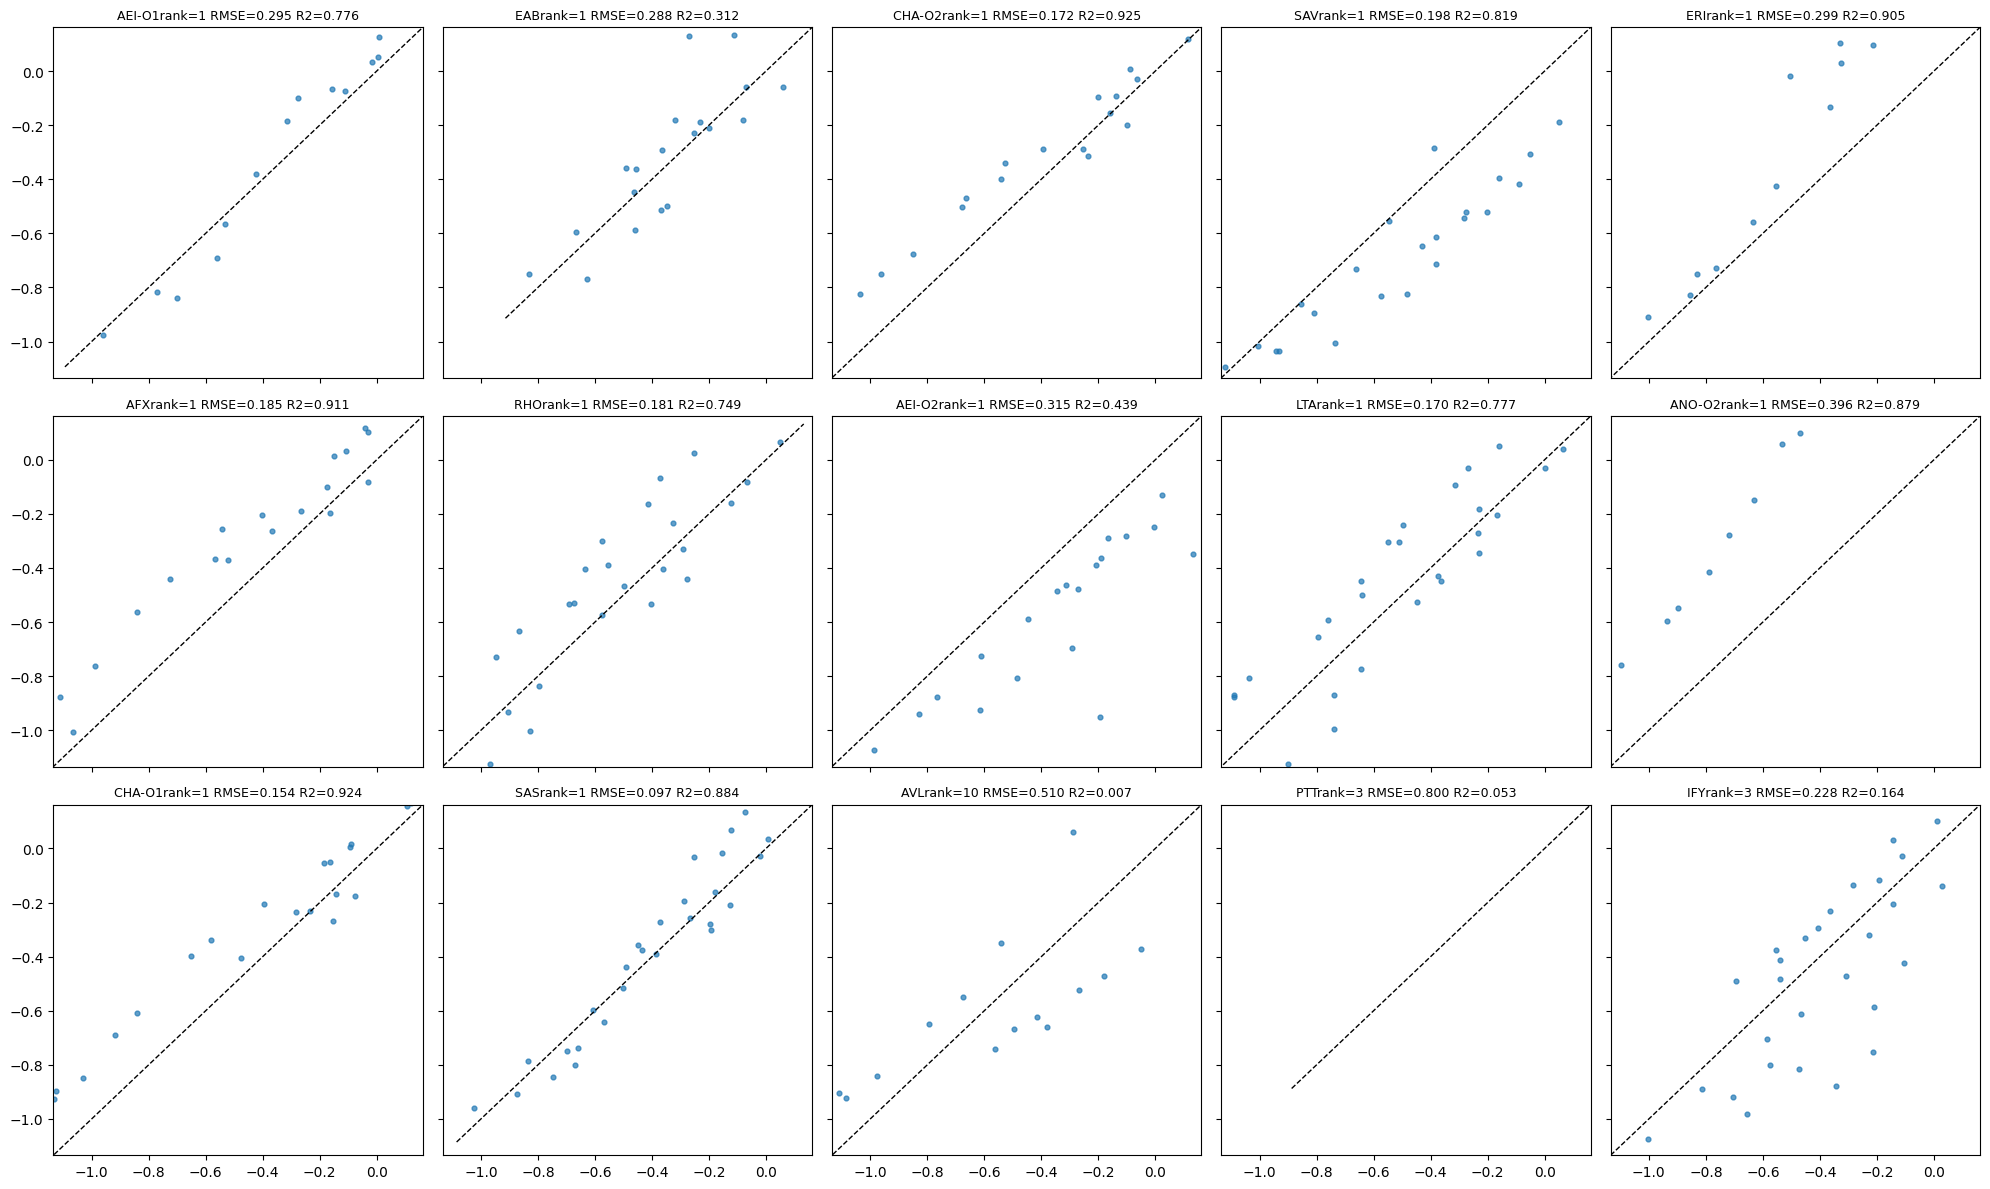

In [52]:
from pathlib import Path
import math
import matplotlib.pyplot as plt
import mt_sisso_scatter as m
import pandas as pd 
df = pd.read_csv('/Users/jayeee/Desktop/code/SRIPT/sisso-out/zeo_fold_EHMB_big-M/2D-1/2D1.csv')
def str2list(str):
    return [t.strip() for t in str.strip("[]").split(",") if t.strip()]
f_idx = 0
tasks=df.iloc[f_idx]['task_list']
ranks = df.iloc[f_idx]['ranks']
tasks = str2list(tasks)
ranks = str2list(ranks)
# print(ranks)
folder = [Path('.') / t for t in tasks]
# print(folder)
print(tasks)
base = Path("/Users/jayeee/Desktop/code/SRIPT/sisso-out/zeo_fold_EHMB_big-M/2D-1/")
runs = []
for t in tasks:
    d = base / t
    if (d / "train.dat").exists() and (d / "predict.dat").exists():
        runs.append(d)
    else:
        raise FileNotFoundError(f"{d} 缺少 train.dat 或 predict.dat")
# base = Path('.')
# runs = [d for d in sorted(folder.iterdir()) if (d/'train.dat').exists() and (d/'predict.dat').exists()]
# if not runs:
#     raise SystemExit('未找到任何含 train.dat/predict.dat 的子目录')

n = len(runs)
if isinstance(ranks, int):
    rank_per_run = [ranks] * n
elif isinstance(ranks, (list, tuple)):
    if len(ranks) != n:
        raise ValueError(f"rank 列表长度 {len(ranks)} 与任务数 {n} 不匹配")
    rank_per_run = ranks
else:
    raise TypeError('rank 需为整数或列表/元组')

rows, cols = 3, 5
rows = rows if n > rows * cols else math.ceil(n / cols)
cols = cols if n > rows * cols else cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4), squeeze=False, sharex=True, sharey=True)
for idx, (ax, run) in enumerate(zip(axes.flat, runs)):
    rank = int(rank_per_run[idx])
    try:
        headers_train, train_rows = m._read_table(run / 'train.dat')
        headers_pred, predict_rows = m._read_table(run / 'predict.dat')
        if headers_train != headers_pred:
            ax.set_title(f"{run.name}header mismatch", fontsize=9)
            ax.axis('off'); continue

        task_index = m._build_task_index(r['materials'] for r in train_rows)
        uspace = m._load_uspace(run / 'SIS_subspaces' / 'Uspace.expressions')
        model_path = m._find_first(run / 'Models', r'top\d+_D\d+')
        coeff_path = m._find_first(run / 'Models', r'top\d+_D\d+_coeff')
        feature_ids = m._load_model_features(model_path, rank)
        desc_dim = len(feature_ids)
        coeffs = m._load_coefficients(coeff_path, rank, len(task_index), desc_dim)
        prepared_exprs = [m._prepare_expression(uspace[fid - 1], headers_train[1:]) for fid in feature_ids]
        # print(coeffs)
        preds = m._predict_dataset(predict_rows, feature_ids, prepared_exprs, coeffs, task_index)
        pts = [(t, p) for t, p, _, _ in preds]
        if not pts:
            ax.set_title(f"{run.name}no data", fontsize=9)
            ax.axis('off'); continue

        rmse, r2 = m._metrics(pts)
        true_vals = [t for t, _ in pts]
        min_val, max_val = min(true_vals + [p for _, p in pts]), max(true_vals + [p for _, p in pts])
        print(min_val, max_val)
        pad = (max_val - min_val) * 0.05 if max_val > min_val else 0.1
        plot_min, plot_max = min_val - pad, max_val + pad

        ax.scatter(true_vals, [p for _, p in pts], s=12, alpha=0.7, color='tab:blue')
        ax.plot([plot_min, plot_max], [plot_min, plot_max], 'k--', lw=1)
        ax.set_xlim(plot_min, plot_max); ax.set_ylim(plot_min, plot_max)
        ax.set_title(f"{run.name}rank={rank} RMSE={rmse:.3f} R2={r2:.3f}", fontsize=9)
    except Exception as e:
        ax.set_title(f"{run.name}{e}", fontsize=9)
        ax.axis('off')

# 关闭多余空白子图
for ax in axes.flat[len(runs):]:
    ax.axis('on')

fig.tight_layout()
fig.savefig('all_runs_predict_grid.png', dpi=400)
print('保存 all_runs_predict_grid.png，包含子图数:', len(runs))

